# Parameterization and Waveform Differences

GWCorrect v0.26.3

In this tutorial, we demonstrate using this package to load in and use parameterized sets of waveform differences as well as how to generate these sets ourselves. This notebook can be downloaded [here](https://github.com/RyanSR71/waveform_uncertainty/blob/main/docs/source/notebooks/Parameterization_and_Waveform_Differences.ipynb).

The following cell is everything we need to import to run this tutorial. We also import the `GWCorrect` package, which will need to be installed first. See [Installation](https://waveformuncertainty.readthedocs.io/en/latest/installation.html#installation).

In [2]:
import os
import numpy as np
import bilby
import matplotlib.pyplot as plt
import random
import requests
import pandas
import GWCorrect.wfu as wfu

In [3]:
# setting matplotlib font to LaTeX font
plt.rcParams['mathtext.fontset'] = 'cm'
plt.rcParams['font.family'] = 'serif'

## Using Parameterized Waveform Differences

We will first demonstrate how parameterized waveform differences are loaded in and used. Here, we load in `BBH_parameterization_nsamples1000.npy`, which contains 1000 samples of parameterized amplitude differences and phase differences from simulated binary black hole merger events.

In [4]:
# downloading the file and saving to a folder
try:
    os.mkdir('tutorial_files')
except:
    pass
file = requests.get('https://github.com/RyanSR71/GWCorrect/raw/refs/heads/main/files/BBH_parameterization_nsamples_1000.npy', allow_redirects=True)
open("tutorial_files/BBH_parameterization_nsamples_1000.npy", 'wb').write(file.content)

# loading the file
parameterization = np.load("tutorial_files/BBH_parameterization_nsamples_1000.npy",allow_pickle=True)

We can use `GWCorrect.wfu.parameterization.recovery_from_parameterization` to turn the parameterized sets of waveform differences back into the waveform differences they represent. This function takes in one row of the parameterization array and constructs the waveform differences from the spline parameters in the file. The function returns the mass weighted dimensionless frequency array ($\xi$), amplitude difference array, and phase difference array. If you want this function to return the waveform differences in SI frequency, set the `dimensionless` arguement to `False`.

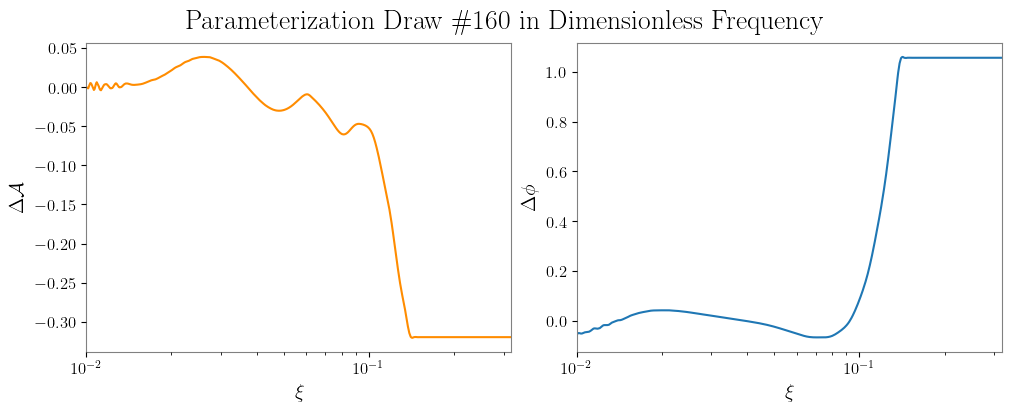

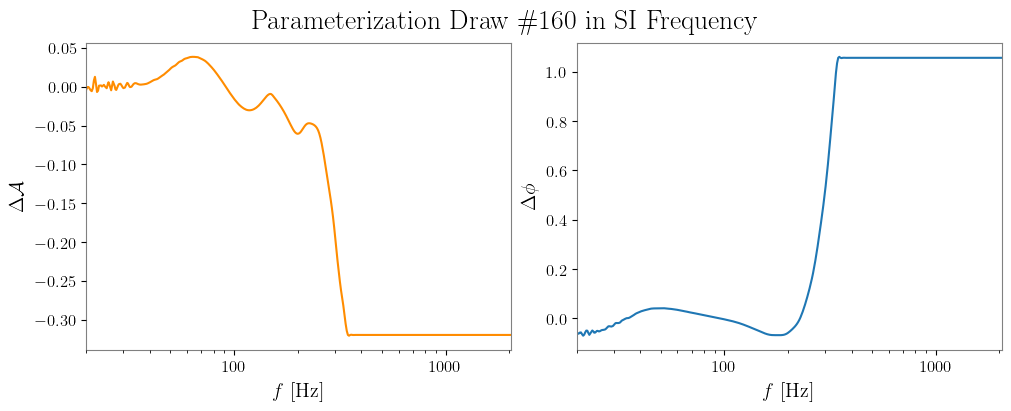

In [5]:
# we can choose any index to recover up to the number of sample sets in the file; in this case, 1000
index = random.randint(0,1000)

# recovering a draw of waveform differences
dimensionless_frequency_grid, amplitude_difference, phase_difference = wfu.parameterization.recovery_from_parameterization(parameterization[index])

# plotting
fig1,ax1 = plt.subplots(1,2,figsize=(10,4),layout='constrained')

# plotting the waveform differences
ax1[0].semilogx(dimensionless_frequency_grid,amplitude_difference,color='darkorange')
ax1[1].semilogx(dimensionless_frequency_grid,phase_difference,color='tab:blue')

# plot settings
ax1[0].grid(False)
ax1[0].set_xlabel(r'$\xi$')
ax1[0].set_ylabel(r'$\Delta\mathcal{A}$')
ax1[0].set_xlim(0.01,dimensionless_frequency_grid[-1])

ax1[1].grid(False)
ax1[1].set_xlabel(r'$\xi$')
ax1[1].set_ylabel(r'$\Delta\phi$')
ax1[1].set_xlim(0.01,dimensionless_frequency_grid[-1])

fig1.suptitle(f'Parameterization Draw \#{index} in Dimensionless Frequency',fontsize=20)

plt.show()

# getting the same draw from the file, but this time in SI frequency
frequency_grid, amplitude_difference, phase_difference = wfu.parameterization.recovery_from_parameterization(parameterization[index],dimensionless=False)

# plotting
fig2,ax2 = plt.subplots(1,2,figsize=(10,4),layout='constrained')

# plotting the waveform differences
ax2[0].semilogx(frequency_grid,amplitude_difference,color='darkorange')
ax2[1].semilogx(frequency_grid,phase_difference,color='tab:blue')

# plot settings
ax2[0].grid(False)
ax2[0].set_xlabel(r'$f\ [\mathrm{Hz}]$')
ax2[0].set_ylabel(r'$\Delta\mathcal{A}$')
ax2[0].set_xlim(frequency_grid[0],frequency_grid[-1])

ax2[1].grid(False)
ax2[1].set_xlabel(r'$f\ [\mathrm{Hz}]$')
ax2[1].set_ylabel(r'$\Delta\phi$')
ax2[1].set_xlim(frequency_grid[0],frequency_grid[-1])

fig2.suptitle(f'Parameterization Draw \#{index} in SI Frequency',fontsize=20)

plt.show()

From a parameterization file, we can use `GWCorrect.wfu.parameterization.uncertainties_from_parameterization` to find the means and standard deviations of each waveform difference, which will show us the expected variability between the waveform models. We represent the means as $\overline{\Delta\mathcal{A}}_\mu$ and $\overline{\Delta\phi}_\mu$, and the standard deviations as $\delta\mathcal{A}_\mu$ and $\delta\phi_\mu$. This function returns the `mean_amplitude_difference`,`mean_phase_difference`,`amplitude_uncertainty`, `phase_uncertainty`, and the `dimensionless_frequency_grid`. To return these quantities in SI frequency, set the `dimensionless` argument to `False`.

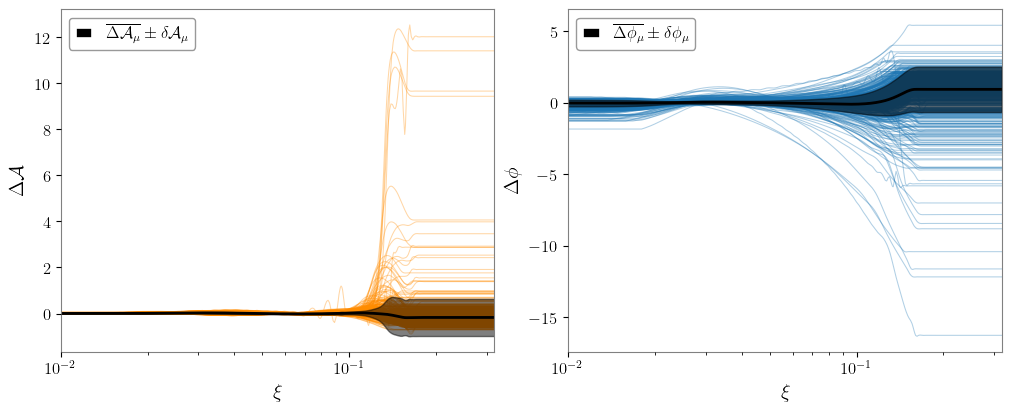

In [6]:
# finding the means and standard deviations
mean_amplitude_difference,amplitude_uncertainty,mean_phase_difference,phase_uncertainty,dimensionless_frequency_grid = wfu.parameterization.uncertainties_from_parameterization(parameterization)

# plotting
fig,ax = plt.subplots(1,2,figsize=(10,4),layout='constrained')

# plotting the means and standard deviations (uncertainties)
ax[0].semilogx(dimensionless_frequency_grid,mean_amplitude_difference,color='k',linewidth=2,zorder=2,label=r'$\overline{\Delta\mathcal{A}_{\mu}}\pm\delta\mathcal{A}_{\mu}$')
ax[0].fill_between(dimensionless_frequency_grid,mean_amplitude_difference-amplitude_uncertainty,mean_amplitude_difference+amplitude_uncertainty,color='k',alpha=0.5,zorder=2)
ax[1].semilogx(dimensionless_frequency_grid,mean_phase_difference,color='k',linewidth=2,zorder=2,label=r'$\overline{\Delta\phi_{\mu}}\pm\delta\phi_{\mu}$')
ax[1].fill_between(dimensionless_frequency_grid,mean_phase_difference-phase_uncertainty,mean_phase_difference+phase_uncertainty,color='k',alpha=0.5,zorder=2)

# plotting all of the draws of waveform difference
for i in range(len(parameterization)):
    dimensionless_frequency_grid, amplitude_difference, phase_difference = wfu.parameterization.recovery_from_parameterization(parameterization[i])
    ax[0].semilogx(dimensionless_frequency_grid,amplitude_difference,color='darkorange',linewidth=0.75,alpha=0.35,zorder=1)
    ax[1].semilogx(dimensionless_frequency_grid,phase_difference,color='tab:blue',linewidth=0.75,alpha=0.35,zorder=1)

# plot settings
ax[0].legend(fancybox=True,loc='upper left')
ax[0].grid(False)
ax[0].set_xlim(0.01,dimensionless_frequency_grid[-1])
ax[0].set_xlabel(r'$\xi$')
ax[0].set_ylabel(r'$\Delta\mathcal{A}$')

ax[1].legend(fancybox=True,loc='upper left')
ax[1].grid(False)
ax[1].set_xlim(0.01,dimensionless_frequency_grid[-1])
ax[1].set_xlabel(r'$\xi$')
ax[1].set_ylabel(r'$\Delta\phi$')

plt.show()

## Waveform Correction Prior Splines from a Parameterization File

When we perform parameter estimation using the amplitude and phase corrected waveform model, our prior distributions for the correction parameters are based on the means and standard deviations of the waveform differences between two waveform models. We define the standard deviations of our priors to be $\sigma_\mathcal{A}=\sqrt{\overline{\Delta\mathcal{A}_\mu}^2+\delta\mathcal{A}_\mu^2}$ for the amplitude corrections and $\sigma_\phi=\sqrt{\overline{\Delta\phi_\mu}^2+\delta\phi_\mu^2}$ for the phase corrections. In the code, we represent these quantities as Scipy cubic spline objects. We can generate these spline using `wfu.parameterization.sigma_splines_from_parameterization`.

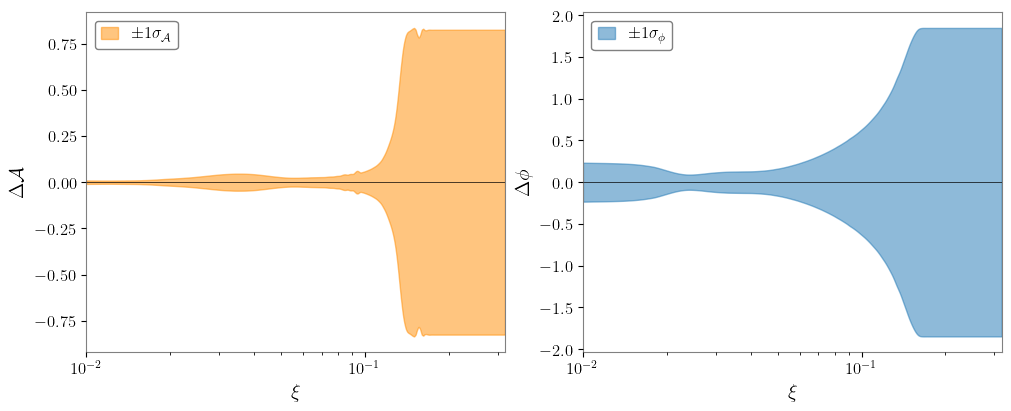

In [7]:
sigma_dA_spline,sigma_dphi_spline = wfu.parameterization.sigma_splines_from_parameterization(parameterization)

# generating an array of dimensionless frequencies to evaluate the splines over
dimensionless_frequency_grid = np.geomspace(0.01,1/np.pi,1000)

fig,ax = plt.subplots(1,2,figsize=(10,4),layout='constrained')

# shortcut for setting the x axis to log spacing
ax[0].semilogx([],[])
ax[0].fill_between(dimensionless_frequency_grid,-sigma_dA_spline(dimensionless_frequency_grid),sigma_dA_spline(dimensionless_frequency_grid),color='darkorange',alpha=0.5,label=r'$\pm1\sigma_\mathcal{A}$')

# shortcut for setting the x axis to log spacing
ax[1].semilogx([],[])
ax[1].fill_between(dimensionless_frequency_grid,-sigma_dphi_spline(dimensionless_frequency_grid),sigma_dphi_spline(dimensionless_frequency_grid),color='tab:blue',alpha=0.5,label=r'$\pm1\sigma_\phi$')

# plot settings
ax[0].legend(fancybox=True,framealpha=1,loc='upper left')
ax[0].axhline(0,color='k',linewidth=0.5)
ax[0].grid(False)
ax[0].set_xlim(0.01,dimensionless_frequency_grid[-1])
ax[0].set_xlabel(r'$\xi$')
ax[0].set_ylabel(r'$\Delta\mathcal{A}$')

ax[1].legend(fancybox=True,framealpha=1,loc='upper left')
ax[1].axhline(0,color='k',linewidth=0.5)
ax[1].grid(False)
ax[1].set_xlim(0.01,dimensionless_frequency_grid[-1])
ax[1].set_xlabel(r'$\xi$')
ax[1].set_ylabel(r'$\Delta\phi$')

plt.show()

## Generating Waveform Model Differences

In the following sections, we look at generating waveform differences and then generating a parameterization file.

We first construct a prior of source parameters over which we want to generate waveform differences. Here, we choose a prior for binary black hole analysis.

In [8]:
prior = bilby.core.prior.PriorDict()

prior['chirp_mass'] = bilby.gw.prior.UniformInComponentsChirpMass(name='chirp_mass',latex_label=r'$\mathcal{M}_c$',minimum=10,maximum=100,unit=r'$\mathrm{M}_{\odot}$')
prior['mass_ratio'] = bilby.gw.prior.UniformInComponentsMassRatio(name='mass_ratio',latex_label=r'$q$',minimum=0.125,maximum=1)
prior['chi_1'] = bilby.core.prior.Uniform(name='chi_1',latex_label=r'$\chi_1$',minimum=-1,maximum=1)
prior['chi_2'] = bilby.gw.prior.Uniform(name='chi_2',latex_label=r'$\chi_2$',minimum=-1,maximum=1)
prior['geocent_time'] = bilby.gw.prior.Uniform(name='geocent_time',latex_label=r'$t_{c}$',minimum=1126259462.4,maximum=1126259462.5,unit='s')
prior['luminosity_distance'] = bilby.gw.prior.UniformSourceFrame(name='luminosity_distance',latex_label=r'$D_L$',minimum=10,maximum=10000,unit='Mpc')
prior['phase'] = bilby.core.prior.Uniform(name='phase',latex_label=r'$\phi_\mathrm{ref}$',minimum=0,maximum=2*np.pi,boundary='periodic')
prior['theta_jn'] = bilby.core.prior.Sine(name='theta_jn',latex_label=r'$\theta_{JN}$')

Here we set up our waveform generators with our injection passed as an argument. Because we are looking to generate model differences, we choose two different waveform approximants, `IMRPhenomD` and `SEOBNRv4`.

In [9]:
waveform_arguments_1 = dict(waveform_approximant='IMRPhenomD', reference_frequency=20.0, 
                            catch_waveform_errors=True, minimum_frequency=20.0, maximum_frequency=2048.0)

hf1 = bilby.gw.WaveformGenerator(parameter_conversion=bilby.gw.conversion.convert_to_lal_binary_black_hole_parameters,
                    waveform_arguments=waveform_arguments_1,
                    frequency_domain_source_model=bilby.gw.source.lal_binary_black_hole,
                    sampling_frequency=4096, 
                    duration=4,
                )

waveform_arguments_2 = dict(waveform_approximant='SEOBNRv4', reference_frequency=20.0, 
                            catch_waveform_errors=True, minimum_frequency=20.0, maximum_frequency=2048.0)

hf2 = bilby.gw.WaveformGenerator(parameter_conversion=bilby.gw.conversion.convert_to_lal_binary_black_hole_parameters,
                    waveform_arguments=waveform_arguments_2,
                    frequency_domain_source_model=bilby.gw.source.lal_binary_black_hole,
                    sampling_frequency=4096, 
                    duration=4,
                )

23:02 bilby INFO    : Waveform generator initiated with
  frequency_domain_source_model: bilby.gw.source.lal_binary_black_hole
  time_domain_source_model: None
  parameter_conversion: bilby.gw.conversion.convert_to_lal_binary_black_hole_parameters
23:02 bilby INFO    : Waveform generator initiated with
  frequency_domain_source_model: bilby.gw.source.lal_binary_black_hole
  time_domain_source_model: None
  parameter_conversion: bilby.gw.conversion.convert_to_lal_binary_black_hole_parameters


With the waveform generators, we can calculate the waveform model differences, $\Delta\mathcal{A}_{\mu}$ and $\Delta\phi_{\mu}$. If we pass the waveform generators into the `GWCorrect.wfu.parameterization.fd_model_difference` function, it will return model amplitude difference, $\Delta\mathcal{A}_{\mu}$, and model phase difference, $\Delta{\phi}_{\mu}$. If injection parameters are not present in the waveform generators, add them to the function using the `injection` argument.

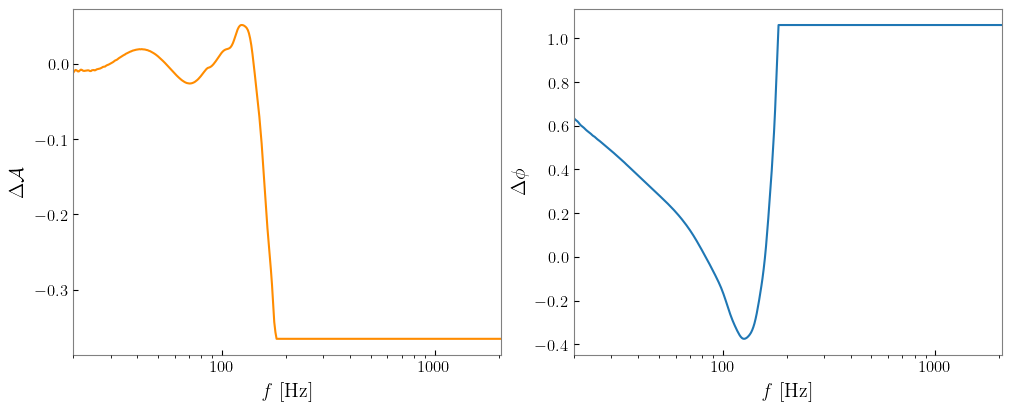

In [10]:
# calculating the waveform model differences
injection=prior.sample()

frequency_grid,amplitude_difference,phase_difference = wfu.parameterization.fd_model_difference(hf1,hf2,injection=injection)

# plotting
fig,ax = plt.subplots(1,2,figsize=(10,4),layout='constrained')

# plotting the waveform differences
ax[0].semilogx(frequency_grid,amplitude_difference,color='darkorange')
ax[1].semilogx(frequency_grid,phase_difference,color='tab:blue')

# plot settings
ax[0].set_xlim(hf1.waveform_arguments['minimum_frequency'],hf1.waveform_arguments['maximum_frequency'])
ax[0].set_xlabel(r'$\mathit{f}$ [Hz]')
ax[0].set_ylabel(r'$\Delta\mathcal{A}$')
ax[0].tick_params(direction='in')
ax[0].grid(False)

ax[1].set_xlim(hf1.waveform_arguments['minimum_frequency'],hf1.waveform_arguments['maximum_frequency'])
ax[1].set_xlabel(r'$\mathit{f}$ [Hz]')
ax[1].set_ylabel(r'$\Delta\phi$')
ax[1].tick_params(direction='in')
ax[1].grid(False)

plt.show()

## Generating a Parameterization File

`GWCorrect.wfu.parameterization.parameterization` takes the previous steps and iterates them many times, but fits a cubic spline function to the waveform differences and saves the spline parameters and the injection parameters in a numpy array. To run the function, we pass two waveform generators, a prior, and the number of draws we want.

Here we define some waveform generators, each with different waveform approximants:

In [11]:
waveform_arguments_1 = dict(waveform_approximant='IMRPhenomD', reference_frequency=20.0, 
                            catch_waveform_errors=True, minimum_frequency=20.0, maximum_frequency=2048.0)

IMR_waveform = bilby.gw.WaveformGenerator(parameter_conversion=bilby.gw.conversion.convert_to_lal_binary_black_hole_parameters,
                    waveform_arguments=waveform_arguments_1,
                    frequency_domain_source_model=bilby.gw.source.lal_binary_black_hole,
                    sampling_frequency=4096, 
                    duration=4,
                )

waveform_arguments_2 = dict(waveform_approximant='SEOBNRv4', reference_frequency=20.0, 
                            catch_waveform_errors=True, minimum_frequency=20.0, maximum_frequency=2048.0)

EOB_waveform = bilby.gw.WaveformGenerator(parameter_conversion=bilby.gw.conversion.convert_to_lal_binary_black_hole_parameters,
                    waveform_arguments=waveform_arguments_2,
                    frequency_domain_source_model=bilby.gw.source.lal_binary_black_hole,
                    sampling_frequency=4096, 
                    duration=4,
                )

Because we want to use this file to construct a waveform uncertainty prior later, we will need to define a new prior. When perform parameter estimation, we need to constrict the total mass to ensure that our waveform uncertainty correction stays inside the frequency band. To be as accurate as possible, we want this restriction to be reflected in the prior. We do this using `GWCorrect.wfu.prior.TotalMassConstraint` as our total mass prior. To allow the prior to use the total mass constraint, we also must pass a conversion function into the `PriorDict` object. Because we are only dealing with total mass, we use the `GWCorrect.wfu.prior.conversion` function with no additional arguemnts.

In [12]:
# we pass the total mass conversion function into the PriorDict() function. this will allow bilby to convert between the given mass parameters and total mass
prior = bilby.core.prior.PriorDict(conversion_function=wfu.prior.conversion)

# here we put in the total mass constraint prior, making sure to use the upper and lower frequencies that we set in the waveform generators
prior['total_mass'] = wfu.prior.TotalMassConstraint(name='total_mass',latex_label=r'$M$',minimum_frequency=20,maximum_frequency=2048,unit=r'$\mathrm{M}_{\odot}$')

prior['chirp_mass'] = bilby.gw.prior.UniformInComponentsChirpMass(name='chirp_mass',latex_label=r'$\mathcal{M}_c$',minimum=10,maximum=100,unit=r'$\mathrm{M}_{\odot}$')
prior['mass_ratio'] = bilby.gw.prior.UniformInComponentsMassRatio(name='mass_ratio',latex_label=r'$q$',minimum=0.125,maximum=1)
prior['chi_1'] = bilby.core.prior.Uniform(name='chi_1',latex_label=r'$\chi_1$',minimum=-1,maximum=1)
prior['chi_2'] = bilby.gw.prior.Uniform(name='chi_2',latex_label=r'$\chi_2$',minimum=-1,maximum=1)
prior['geocent_time'] = bilby.gw.prior.Uniform(name='geocent_time',latex_label=r'$t_{c}$',minimum=1126259462.4,maximum=1126259462.5,unit='s')
prior['luminosity_distance'] = bilby.gw.prior.UniformSourceFrame(name='luminosity_distance',latex_label=r'$D_L$',minimum=10,maximum=10000,unit='Mpc')
prior['phase'] = bilby.core.prior.Uniform(name='phase',latex_label=r'$\phi_\mathrm{ref}$',minimum=0,maximum=2*np.pi,boundary='periodic')
prior['theta_jn'] = bilby.core.prior.Sine(name='theta_jn',latex_label=r'$\theta_{JN}$')

Now we can generate the parameterization file, passing in both waveform generators and the prior. We choose our sample size to be 25 for this demonstration.

In [13]:
parameterization=wfu.parameterization.parameterization(IMR_waveform,EOB_waveform,prior,25)

Generating Waveform Differences: 100%|██████████| 25/25 [00:18<00:00,  1.38it/s]


This can then be saved as a `.npy` file using `numpy.save`.

In [14]:
try:
    os.mkdir('tutorial_files')
except:
    pass

np.save('tutorial_files/parameterization_example.npy',parameterization)

We can use [pandas](https://pandas.pydata.org/) dataframes to see the structure of the parameterization table:

In [15]:
pandas.DataFrame(parameterization,columns = ['Frequency Grid','Frequency Spline Nodes','Amplitude Difference Spline Parameters','Phase Difference Spline Parameters','Injection Parameters'])

,Frequency Grid,Frequency Spline Nodes,Amplitude Difference Spline Parameters,Phase Difference Spline Parameters,Injection Parameters
0,"[20.0, 20.25, 20.5, 20.75, 21.0, 21.25, 21.5, ...","[20.0, 20.5, 21.0, 21.5, 22.0, 22.5, 23.0, 23....","[0.010408891334551695, 0.01053589734562399, -0...","[0.027910137297832593, 0.06107089799941545, 0....","{'chirp_mass': 29.601431000275586, 'mass_ratio..."
1,"[20.0, 20.25, 20.5, 20.75, 21.0, 21.25, 21.5, ...","[20.0, 20.5, 21.0, 21.5, 22.0, 22.5, 23.0, 23....","[-0.006457724190772174, -0.001060135103097104,...","[0.020683424697303998, 0.01909164940985386, 0....","{'chirp_mass': 67.58627297032123, 'mass_ratio'..."
2,"[20.0, 20.25, 20.5, 20.75, 21.0, 21.25, 21.5, ...","[20.0, 20.5, 21.0, 21.5, 22.0, 22.5, 23.0, 23....","[0.013081812864635278, 0.007031145394392979, -...","[0.06974576363969427, 0.09924756874777466, 0.0...","{'chirp_mass': 25.38839089896505, 'mass_ratio'..."
3,"[20.0, 20.25, 20.5, 20.75, 21.0, 21.25, 21.5, ...","[20.0, 20.5, 21.0, 21.5, 22.0, 22.5, 23.0, 23....","[-0.001343859468254549, -0.0010046951334299337...","[-0.005361001015708133, -0.005037365773973068,...","{'chirp_mass': 71.18883481023948, 'mass_ratio'..."
4,"[20.0, 20.25, 20.5, 20.75, 21.0, 21.25, 21.5, ...","[20.0, 20.5, 21.0, 21.5, 22.0, 22.5, 23.0, 23....","[0.015586480713347006, 0.0027582679659430287, ...","[-0.041538879158447006, -0.025902380951199344,...","{'chirp_mass': 39.708154075828475, 'mass_ratio..."
5,"[20.0, 20.25, 20.5, 20.75, 21.0, 21.25, 21.5, ...","[20.0, 20.5, 21.0, 21.5, 22.0, 22.5, 23.0, 23....","[-0.004053688034778458, -0.001933658059802501,...","[0.2850946545727733, 0.27412730953188125, 0.26...","{'chirp_mass': 58.948428623179325, 'mass_ratio..."
6,"[20.0, 20.25, 20.5, 20.75, 21.0, 21.25, 21.5, ...","[20.0, 20.5, 21.0, 21.5, 22.0, 22.5, 23.0, 23....","[-0.007851044210671732, 0.007344255021813018, ...","[-0.20147158636015217, -0.19418274299054472, -...","{'chirp_mass': 53.918051110912536, 'mass_ratio..."
7,"[20.0, 20.25, 20.5, 20.75, 21.0, 21.25, 21.5, ...","[20.0, 20.5, 21.0, 21.5, 22.0, 22.5, 23.0, 23....","[-0.0017108025516694436, -0.002937061681077768...","[0.1934731124517448, 0.1962768357556688, 0.189...","{'chirp_mass': 51.298182006835816, 'mass_ratio..."
8,"[20.0, 20.25, 20.5, 20.75, 21.0, 21.25, 21.5, ...","[20.0, 20.5, 21.0, 21.5, 22.0, 22.5, 23.0, 23....","[-0.010184367066581324, -0.009618393337281983,...","[0.07795086138042517, 0.07537041469923667, 0.0...","{'chirp_mass': 50.178715592731585, 'mass_ratio..."
9,"[20.0, 20.25, 20.5, 20.75, 21.0, 21.25, 21.5, ...","[20.0, 20.5, 21.0, 21.5, 22.0, 22.5, 23.0, 23....","[-0.002878820158239259, -0.0013995357735978597...","[0.04566147203130777, 0.03910625934983081, 0.0...","{'chirp_mass': 69.21890215571496, 'mass_ratio'..."
